Non-Referable DR = { mild, moderate }
Referable DR     = { severe, proliferative }


In [1]:
import os, shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
train_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [3]:
SRC = "../data/severity"
DST = "../data/referable_binary"

for split in ["train", "val", "test"]:
    for cls in ["non_referable", "referable"]:
        os.makedirs(f"{DST}/{split}/{cls}", exist_ok=True)

    # Non-referable = mild + moderate
    for cls in ["mild", "moderate"]:
        src_dir = f"{SRC}/{split}/{cls}"
        dst_dir = f"{DST}/{split}/non_referable"
        for img in os.listdir(src_dir):
            shutil.copy(f"{src_dir}/{img}", f"{dst_dir}/{img}")

    # Referable = severe + proliferative
    for cls in ["severe", "proliferative"]:
        src_dir = f"{SRC}/{split}/{cls}"
        dst_dir = f"{DST}/{split}/referable"
        for img in os.listdir(src_dir):
            shutil.copy(f"{src_dir}/{img}", f"{dst_dir}/{img}")

print("Binary Referable dataset created")


KeyboardInterrupt: 

In [4]:
DATA_DIR = "../data/referable_binary"

train_ds = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{DATA_DIR}/val", transform=val_test_transform)
test_ds  = datasets.ImageFolder(f"{DATA_DIR}/test", transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

print("Classes:", train_ds.classes)


Classes: ['non_referable', 'referable']


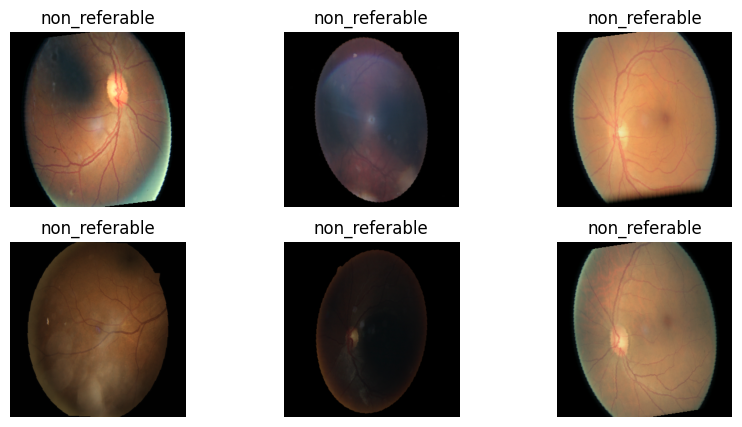

In [5]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].permute(1,2,0).cpu()
    img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])
    plt.imshow(img)
    plt.title(train_ds.classes[labels[i]])
    plt.axis("off")
plt.show()


In [6]:
model = models.efficientnet_b3(pretrained=True)

for p in model.parameters():
    p.requires_grad = False

model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)


C:\Users\anant\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\anant\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3
)


In [8]:
best_acc = 0
best_state = None

for epoch in range(10):
    model.train()
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            preds.extend(torch.argmax(out,1).cpu())
            trues.extend(y.cpu())

    acc = accuracy_score(trues, preds)
    if acc > best_acc:
        best_acc = acc
        best_state = model.state_dict()

    print(f"[Stage-A] Epoch {epoch+1}/10 | Val Acc: {acc:.4f}")

model.load_state_dict(best_state)
print("Best Binary Val Acc:", best_acc)


[Stage-A] Epoch 1/10 | Val Acc: 0.8604
[Stage-A] Epoch 2/10 | Val Acc: 0.8597
[Stage-A] Epoch 3/10 | Val Acc: 0.8676
[Stage-A] Epoch 4/10 | Val Acc: 0.8618
[Stage-A] Epoch 5/10 | Val Acc: 0.8669
[Stage-A] Epoch 6/10 | Val Acc: 0.8669
[Stage-A] Epoch 7/10 | Val Acc: 0.8561
[Stage-A] Epoch 8/10 | Val Acc: 0.8697
[Stage-A] Epoch 9/10 | Val Acc: 0.8597
[Stage-A] Epoch 10/10 | Val Acc: 0.8633
Best Binary Val Acc: 0.8697208303507517


Overall Accuracy: 0.8669527896995708
               precision    recall  f1-score   support

non_referable       0.88      0.98      0.92      1161
    referable       0.73      0.34      0.46       237

     accuracy                           0.87      1398
    macro avg       0.81      0.66      0.69      1398
 weighted avg       0.85      0.87      0.85      1398



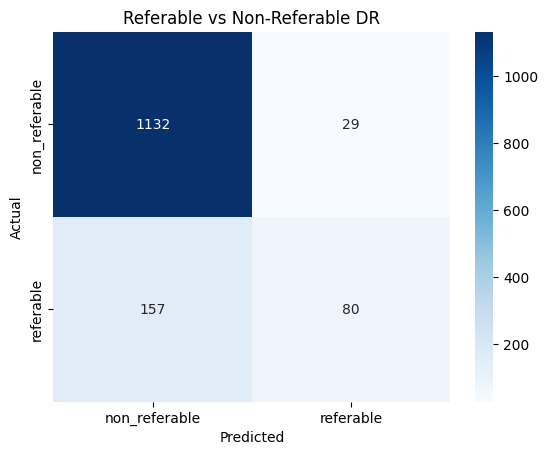

In [9]:
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        out = model(x)
        preds = torch.argmax(out,1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y.numpy())

print("Overall Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=train_ds.classes))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Referable vs Non-Referable DR")
plt.show()


In [10]:
import os
os.makedirs("../models", exist_ok=True)

torch.save(model.state_dict(), "../models/referable_binary_model.pth")
print("Stage-A (Referable vs Non-Referable) model saved")


Stage-A (Referable vs Non-Referable) model saved


🧠 STAGE-B: REFERABLE SUB-CLASSIFICATION

In [11]:
STAGE_B_CLASSES = ["proliferative", "severe"]

# Load the already trained Stage-B model
model_b = models.efficientnet_b3(pretrained=False)
model_b.classifier[1] = nn.Linear(model_b.classifier[1].in_features, 2)
model_b = model_b.to(device)

model_b.load_state_dict(torch.load("../models/stage2_model.pth"))
model_b.eval()

print("Stage-B model loaded")


C:\Users\anant\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\anant\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\anant\AppData\Local\Temp\ipykernel_34572\635221787.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default va

Stage-B model loaded


In [12]:
REFERABLE_TEST_DIR = "../data/severity/test"

referable_ds = datasets.ImageFolder(
    REFERABLE_TEST_DIR,
    transform=val_test_transform
)

# Keep only severe + proliferative
referable_indices = [
    i for i, (_, y) in enumerate(referable_ds.samples)
    if referable_ds.classes[y] in ["severe", "proliferative"]
]

from torch.utils.data import Subset
referable_test_ds = Subset(referable_ds, referable_indices)

referable_test_loader = DataLoader(
    referable_test_ds,
    batch_size=16,
    shuffle=False
)

print("Referable samples:", len(referable_test_ds))


Referable samples: 237


In [8]:
y_true_b = []
y_pred_b = []

with torch.no_grad():
    for x, y in referable_test_loader:
        x = x.to(device)
        out = model_b(x)
        preds = torch.argmax(out, dim=1).cpu().numpy()

        for i in range(len(preds)):
            y_pred_b.append(STAGE_B_CLASSES[preds[i]])
            y_true_b.append(referable_ds.classes[y[i]])


NameError: name 'referable_test_loader' is not defined

Stage-B Accuracy: 0.6919831223628692
               precision    recall  f1-score   support

proliferative       0.62      0.82      0.70       106
       severe       0.80      0.59      0.68       131

     accuracy                           0.69       237
    macro avg       0.71      0.70      0.69       237
 weighted avg       0.72      0.69      0.69       237



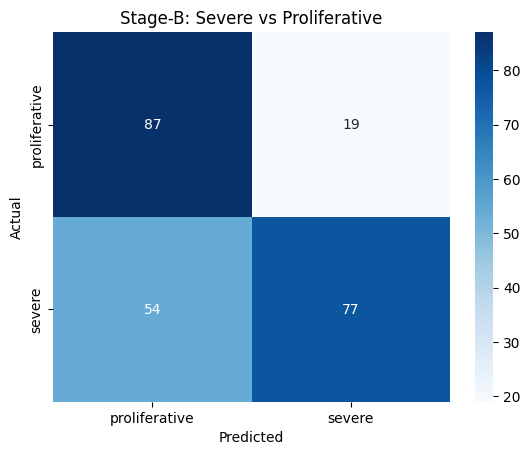

In [14]:
print("Stage-B Accuracy:",
      accuracy_score(y_true_b, y_pred_b))

print(
    classification_report(
        y_true_b,
        y_pred_b,
        labels=STAGE_B_CLASSES
    )
)

cm_b = confusion_matrix(
    y_true_b,
    y_pred_b,
    labels=STAGE_B_CLASSES
)

sns.heatmap(
    cm_b, annot=True, fmt="d",
    xticklabels=STAGE_B_CLASSES,
    yticklabels=STAGE_B_CLASSES,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stage-B: Severe vs Proliferative")
plt.show()


In [15]:
def full_pipeline_predict(img_tensor):
    # Stage-A
    out_a = model(img_tensor)
    pred_a = torch.argmax(out_a, dim=1).item()

    if pred_a == 0:
        return "non_referable"

    # Stage-B
    out_b = model_b(img_tensor)
    pred_b = torch.argmax(out_b, dim=1).item()
    return STAGE_B_CLASSES[pred_b]


In [17]:
CLASS_NAMES = ["non_referable", "referable"]


In [9]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# create results folder if not exists
os.makedirs("../results", exist_ok=True)

# compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stage-A Confusion Matrix: Referable vs Non-Referable DR")

# save
plt.savefig("../results/stageA_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.close()

print("Stage-A confusion matrix saved in results/")


NameError: name 'y_true' is not defined

In [11]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_s2 = models.efficientnet_b3(pretrained=False)
model_s2.classifier[1] = nn.Linear(
    model_s2.classifier[1].in_features,
    2   # proliferative vs severe
)

model_s2 = model_s2.to(device)


C:\Users\anant\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [12]:
model_s2.load_state_dict(
    torch.load("../models/stage2_model.pth", map_location=device)
)

model_s2.eval()
print("Stage-B model loaded successfully")


Stage-B model loaded successfully


C:\Users\anant\AppData\Local\Temp\ipykernel_20144\1416401779.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("../models/stage2_model.pth", map_location=device

In [13]:
print(test_loader)


In [1]:
y_true_b = []
y_pred_b = []

STAGE_B_CLASSES = ["proliferative", "severe"]

model_s2.eval()

with torch.no_grad():
    for x, y in test_loader:   # <-- Stage-B test_loader
        x = x.to(device)

        outputs = model_s2(x)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        for i in range(len(preds)):
            y_pred_b.append(STAGE_B_CLASSES[preds[i]])
            y_true_b.append(STAGE_B_CLASSES[y[i].item()])

print("Stage-B samples:", len(y_true_b))


NameError: name 'model_s2' is not defined

In [15]:
import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(
    y_true_b,
    y_pred_b,
    target_names=STAGE_B_CLASSES,
    output_dict=True
)

# save as CSV
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv("../results/stageB_classification_report.csv")

# save as text
with open("../results/stageB_classification_report.txt", "w") as f:
    f.write(
        classification_report(
            y_true_b,
            y_pred_b,
            target_names=STAGE_B_CLASSES
        )
    )

print("Stage-B classification report saved (CSV + TXT)")


Stage-B classification report saved (CSV + TXT)


In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_b = confusion_matrix(
    y_true_b,
    y_pred_b,
    labels=STAGE_B_CLASSES
)

# save CSV
cm_df = pd.DataFrame(
    cm_b,
    index=STAGE_B_CLASSES,
    columns=STAGE_B_CLASSES
)
cm_df.to_csv("../results/stageB_confusion_matrix.csv")

# save image
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_b,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=STAGE_B_CLASSES,
    yticklabels=STAGE_B_CLASSES
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stage-B Confusion Matrix: Severe vs Proliferative")

plt.savefig("../results/stageB_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.close()

print("Stage-B confusion matrix saved (CSV + PNG)")


Stage-B confusion matrix saved (CSV + PNG)


In [4]:
from torchvision import models
import torch.nn as nn

model_stage1 = models.efficientnet_b3(weights=None)

model_stage1.classifier[1] = nn.Linear(
    model_stage1.classifier[1].in_features,
    2
)


In [5]:
model_stage1.load_state_dict(
    torch.load("../models/stage1_referable_model.pth", map_location=device)
)

model_stage1 = model_stage1.to(device)
model_stage1.eval()

print("Stage-1 model loaded successfully.")


C:\Users\anant\AppData\Local\Temp\ipykernel_34468\2561301762.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("../models/stage1_referable_model.pth", map_locat

Stage-1 model loaded successfully.


In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DATA_DIR = "../dataset/severity_data/referable_binary"

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

test_ds = datasets.ImageFolder(
    f"{DATA_DIR}/test",
    transform=val_test_transform
)

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False
)

print("Test loader ready.")


Test loader ready.


In [7]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_stage1.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model_stage1(x)

        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of referable
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

print("Collected probabilities for threshold tuning.")


Collected probabilities for threshold tuning.


In [11]:
best_f1 = 0
best_thresh = 0

for t in thresholds:
    preds = (all_probs > t).astype(int)

    acc = accuracy_score(all_labels, preds)
    prec = precision_score(all_labels, preds)
    rec = recall_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)

    print(f"{t:.2f} | Acc {acc:.3f} | Prec {prec:.3f} | Rec {rec:.3f} | F1 {f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("\nBest threshold (by F1):", best_thresh)
print("Best F1:", best_f1)


0.10 | Acc 0.458 | Prec 0.224 | Rec 0.895 | F1 0.359
0.15 | Acc 0.609 | Prec 0.275 | Rec 0.802 | F1 0.410
0.20 | Acc 0.696 | Prec 0.327 | Rec 0.747 | F1 0.454
0.25 | Acc 0.748 | Prec 0.363 | Rec 0.646 | F1 0.465
0.30 | Acc 0.789 | Prec 0.411 | Rec 0.565 | F1 0.476
0.35 | Acc 0.824 | Prec 0.482 | Rec 0.511 | F1 0.496
0.40 | Acc 0.830 | Prec 0.497 | Rec 0.418 | F1 0.454
0.45 | Acc 0.845 | Prec 0.563 | Rec 0.376 | F1 0.451
0.50 | Acc 0.853 | Prec 0.630 | Rec 0.316 | F1 0.421
0.55 | Acc 0.847 | Prec 0.632 | Rec 0.232 | F1 0.340
0.60 | Acc 0.843 | Prec 0.627 | Rec 0.177 | F1 0.276
0.65 | Acc 0.840 | Prec 0.659 | Rec 0.122 | F1 0.206
0.70 | Acc 0.838 | Prec 0.667 | Rec 0.084 | F1 0.150
0.75 | Acc 0.833 | Prec 0.600 | Rec 0.038 | F1 0.071
0.80 | Acc 0.832 | Prec 0.667 | Rec 0.017 | F1 0.033
0.85 | Acc 0.830 | Prec 0.500 | Rec 0.004 | F1 0.008

Best threshold (by F1): 0.3500000000000001
Best F1: 0.4959016393442623


In [12]:
best_preds = (all_probs > best_thresh).astype(int)

print("\nFinal Evaluation at Best Threshold")
print("Accuracy:", accuracy_score(all_labels, best_preds))
print("Precision:", precision_score(all_labels, best_preds))
print("Recall:", recall_score(all_labels, best_preds))
print("F1:", f1_score(all_labels, best_preds))



Final Evaluation at Best Threshold
Accuracy: 0.8240343347639485
Precision: 0.4820717131474104
Recall: 0.510548523206751
F1: 0.4959016393442623


In [13]:
BEST_STAGE1_THRESHOLD = best_thresh

with open("../models/stage1_threshold.txt", "w") as f:
    f.write(str(BEST_STAGE1_THRESHOLD))

print("Stage-1 threshold saved:", BEST_STAGE1_THRESHOLD)


Stage-1 threshold saved: 0.3500000000000001


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs("../results/stage1_referable", exist_ok=True)

final_preds = (all_probs > BEST_STAGE1_THRESHOLD).astype(int)


In [16]:
report = classification_report(
    all_labels,
    final_preds,
    target_names=["non_referable", "referable"]
)

print(report)

with open("../results/stage1_referable/stage1_classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved.")


               precision    recall  f1-score   support

non_referable       0.90      0.89      0.89      1161
    referable       0.48      0.51      0.50       237

     accuracy                           0.82      1398
    macro avg       0.69      0.70      0.69      1398
 weighted avg       0.83      0.82      0.83      1398

Classification report saved.


In [17]:
cm = confusion_matrix(all_labels, final_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["non_referable", "referable"],
            yticklabels=["non_referable", "referable"],
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stage-1 Referable DR Confusion Matrix (Tuned Threshold)")
plt.tight_layout()
plt.savefig("../results/stage1_referable/stage1_confusion_matrix.png")
plt.close()

pd.DataFrame(cm).to_csv(
    "../results/stage1_referable/stage1_confusion_matrix.csv",
    index=False
)

print("Confusion matrix saved.")


Confusion matrix saved.


In [18]:
metrics = {
    "Accuracy": accuracy_score(all_labels, final_preds),
    "Precision": precision_score(all_labels, final_preds),
    "Recall": recall_score(all_labels, final_preds),
    "F1": f1_score(all_labels, final_preds),
    "Threshold": BEST_STAGE1_THRESHOLD
}

pd.DataFrame([metrics]).to_csv(
    "../results/stage1_referable/stage1_metrics.csv",
    index=False
)

print("Metrics summary saved.")


Metrics summary saved.
